In [2]:
'''
Notebook to understand exploration vs exploitation in RL.

The problem:
  You face k slot machines ("one-armed bandits"). Each arm i pays out
  a reward drawn from a Normal(q*(i), 1) distribution, where q*(i) is
  unknown to you and fixed for the duration of a run. Your goal is to
  maximize total reward over many pulls by balancing:
    - exploitation: pulling the arm you currently think is best
    - exploration: trying other arms to learn more about them

This script compares three action-selection strategies:
  1. Greedy (epsilon = 0)      -> pure exploitation
  2. Epsilon-greedy (eps=0.1)  -> mostly exploit, sometimes explore
  3. Epsilon-greedy (eps=0.01) -> explore rarely

For each strategy we run many independent bandit problems (to average
out luck) and track:
  - average reward per step
  - % of steps where the optimal arm was chosen

'''

'\nNotebook to understand exploration vs exploitation in RL.\n\nThe problem:\n  You face k slot machines ("one-armed bandits"). Each arm i pays out\n  a reward drawn from a Normal(q*(i), 1) distribution, where q*(i) is\n  unknown to you and fixed for the duration of a run. Your goal is to\n  maximize total reward over many pulls by balancing:\n    - exploitation: pulling the arm you currently think is best\n    - exploration: trying other arms to learn more about them\n \nThis script compares three action-selection strategies:\n  1. Greedy (epsilon = 0)      -> pure exploitation\n  2. Epsilon-greedy (eps=0.1)  -> mostly exploit, sometimes explore\n  3. Epsilon-greedy (eps=0.01) -> explore rarely\n \nFor each strategy we run many independent bandit problems (to average\nout luck) and track:\n  - average reward per step\n  - % of steps where the optimal arm was chosen\n\n'

In [1]:
import numpy as np
import matplotlib.pyplot as plt


class Bandit:
    """A single k-armed bandit problem instance."""

    def __init__(self, k=10, seed=None):
        rng = np.random.default_rng(seed)
        # true action values, drawn once per bandit instance
        self.q_true = rng.normal(0, 1, size=k)
        self.k = k
        self.optimal_action = np.argmax(self.q_true)
        self.rng = rng

    def pull(self, action):
        # reward is noisy around the true value of that arm
        return self.rng.normal(self.q_true[action], 1)


In [3]:
class EpsilonGreedyAgent:
    """Estimates action values with sample averages; picks actions
    greedily most of the time, randomly with probability epsilon."""

    def __init__(self, k=10, epsilon=0.1, rng=None):
        self.k = k
        self.epsilon = epsilon
        self.q_est = np.zeros(k)     # current value estimates
        self.action_counts = np.zeros(k)
        self.rng = rng or np.random.default_rng()

    def select_action(self):
        if self.rng.random() < self.epsilon:
            return self.rng.integers(self.k)          # explore
        return np.argmax(self.q_est)                  # exploit

    def update(self, action, reward):
        self.action_counts[action] += 1
        # incremental sample-average update:
        # NewEstimate = OldEstimate + (1/N) * (Reward - OldEstimate)
        step_size = 1.0 / self.action_counts[action]
        self.q_est[action] += step_size * (reward - self.q_est[action])


In [4]:
def run_experiment(epsilons, k=10, n_runs=2000, n_steps=1000, seed=0):
    """Run each epsilon setting over many independent bandit problems
    and average the results."""
    rng = np.random.default_rng(seed)
    results = {}

    for eps in epsilons:
        rewards = np.zeros((n_runs, n_steps))
        optimal_action_pct = np.zeros((n_runs, n_steps))

        for run in range(n_runs):
            bandit = Bandit(k=k, seed=rng.integers(1_000_000))
            agent = EpsilonGreedyAgent(k=k, epsilon=eps, rng=rng)

            for t in range(n_steps):
                action = agent.select_action()
                reward = bandit.pull(action)
                agent.update(action, reward)

                rewards[run, t] = reward
                optimal_action_pct[run, t] = (action == bandit.optimal_action)

        results[eps] = {
            "avg_reward": rewards.mean(axis=0),
            "pct_optimal": optimal_action_pct.mean(axis=0) * 100,
        }
        print(f"epsilon={eps:<5} done "
              f"(final avg reward={results[eps]['avg_reward'][-1]:.3f}, "
              f"final %optimal={results[eps]['pct_optimal'][-1]:.1f}%)")

    return results


In [5]:
def plot_results(results, out_path="bandit_results.png"):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))

    for eps, data in results.items():
        label = f"epsilon = {eps}" if eps > 0 else "greedy (epsilon = 0)"
        ax1.plot(data["avg_reward"], label=label)
        ax2.plot(data["pct_optimal"], label=label)

    ax1.set_xlabel("Steps")
    ax1.set_ylabel("Average reward")
    ax1.set_title("Average reward over time")
    ax1.legend()

    ax2.set_xlabel("Steps")
    ax2.set_ylabel("% optimal action")
    ax2.set_title("% of time the optimal action was chosen")
    ax2.legend()

    fig.tight_layout()
    fig.savefig(out_path, dpi=150)
    print(f"\nSaved plot to {out_path}")


epsilon=0     done (final avg reward=0.968, final %optimal=35.6%)
epsilon=0.1   done (final avg reward=1.333, final %optimal=78.4%)
epsilon=0.01  done (final avg reward=1.325, final %optimal=60.6%)
epsilon=0.15  done (final avg reward=1.295, final %optimal=78.4%)

Saved plot to bandit_results.png


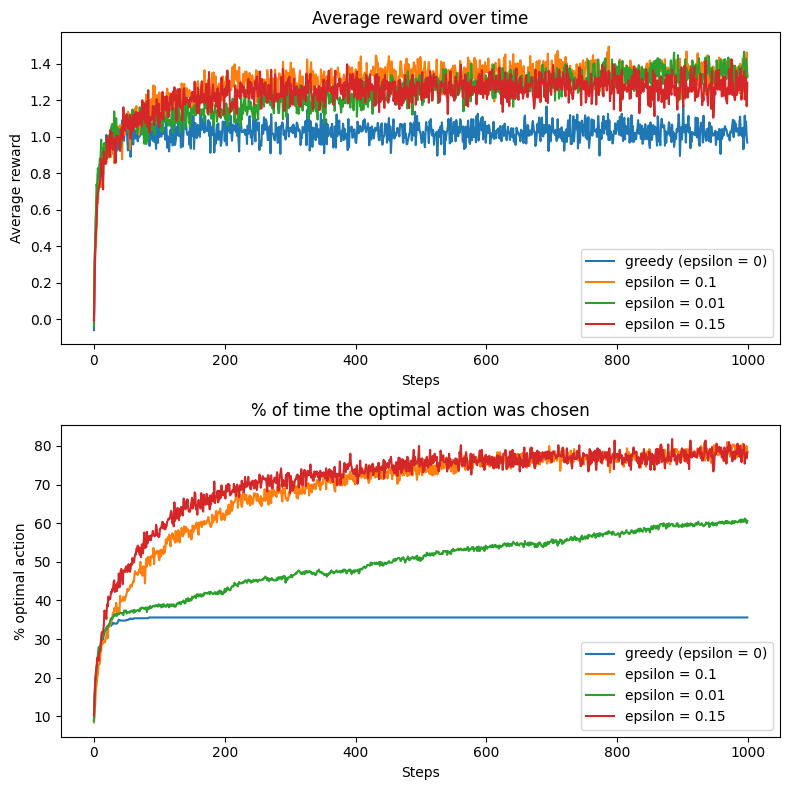

In [8]:
if __name__ == "__main__":
    # Fewer runs/steps by default so it finishes quickly;
    # bump n_runs to 2000 and n_steps to 1000 for the classic textbook figure.
    results = run_experiment(
        epsilons=[0, 0.1, 0.01,0.15],
        k=10,
        n_runs=500,
        n_steps=1000,
        seed=42,
    )
    plot_results(results)


### Influence of parameter k & num_steps

In [13]:
def run_k_vs_steps_sweep(k_values, n_steps_values, epsilon=0.1,
                          n_runs=300, seed=0):
    """For a fixed epsilon, show that %optimal-action at the end of
    the run climbs back up toward the same ceiling as k grows, as
    long as you give it enough steps. This isolates "more arms" as
    a data-budget problem rather than some inherent extra randomness.

    Returns a dict: {k: [final_pct_optimal for each n_steps in n_steps_values]}
    """
    rng = np.random.default_rng(seed)
    sweep_results = {k: [] for k in k_values}

    for k in k_values:
        for n_steps in n_steps_values:
            optimal_hits = np.zeros(n_runs)
            for run in range(n_runs):
                bandit = Bandit(k=k, seed=rng.integers(1_000_000))
                agent = EpsilonGreedyAgent(k=k, epsilon=epsilon, rng=rng)

                is_optimal_last_100 = []
                for t in range(n_steps):
                    action = agent.select_action()
                    reward = bandit.pull(action)
                    agent.update(action, reward)
                    if t >= n_steps - 100:  # average over last 100 steps
                        is_optimal_last_100.append(action == bandit.optimal_action)

                optimal_hits[run] = np.mean(is_optimal_last_100)

            final_pct = optimal_hits.mean() * 100
            sweep_results[k].append(final_pct)
            print(f"k={k:<3} n_steps={n_steps:<6} "
                  f"-> %optimal (last 100 steps, avg)={final_pct:.1f}%")

    return sweep_results


def plot_sweep(sweep_results, n_steps_values, out_path="k_vs_steps_sweep.png"):
    fig, ax = plt.subplots(figsize=(8, 5))
    for k, pct_values in sweep_results.items():
        ax.plot(n_steps_values, pct_values, marker="o", label=f"k = {k}")

    ax.set_xscale("log")
    ax.set_xlabel("Number of steps (log scale)")
    ax.set_ylabel("% optimal action (last 100 steps, averaged)")
    ax.set_title("More arms just need more steps to catch up")
    ax.legend()
    ax.grid(alpha=0.3)

    fig.tight_layout()
    fig.savefig(out_path, dpi=150)
    print(f"\nSaved plot to {out_path}")


epsilon=0     done (final avg reward=0.968, final %optimal=35.6%)
epsilon=0.1   done (final avg reward=1.333, final %optimal=78.4%)
epsilon=0.01  done (final avg reward=1.325, final %optimal=60.6%)

Saved plot to bandit_results.png

--- k vs n_steps sweep (epsilon=0.1) ---
k=2   n_steps=200    -> %optimal (last 100 steps, avg)=87.9%
k=2   n_steps=500    -> %optimal (last 100 steps, avg)=89.4%
k=2   n_steps=1000   -> %optimal (last 100 steps, avg)=92.7%
k=2   n_steps=2000   -> %optimal (last 100 steps, avg)=93.2%
k=2   n_steps=5000   -> %optimal (last 100 steps, avg)=94.3%
k=2   n_steps=10000  -> %optimal (last 100 steps, avg)=93.5%
k=10  n_steps=200    -> %optimal (last 100 steps, avg)=58.9%
k=10  n_steps=500    -> %optimal (last 100 steps, avg)=76.1%
k=10  n_steps=1000   -> %optimal (last 100 steps, avg)=79.8%
k=10  n_steps=2000   -> %optimal (last 100 steps, avg)=81.3%
k=10  n_steps=5000   -> %optimal (last 100 steps, avg)=86.3%
k=10  n_steps=10000  -> %optimal (last 100 steps, avg)=

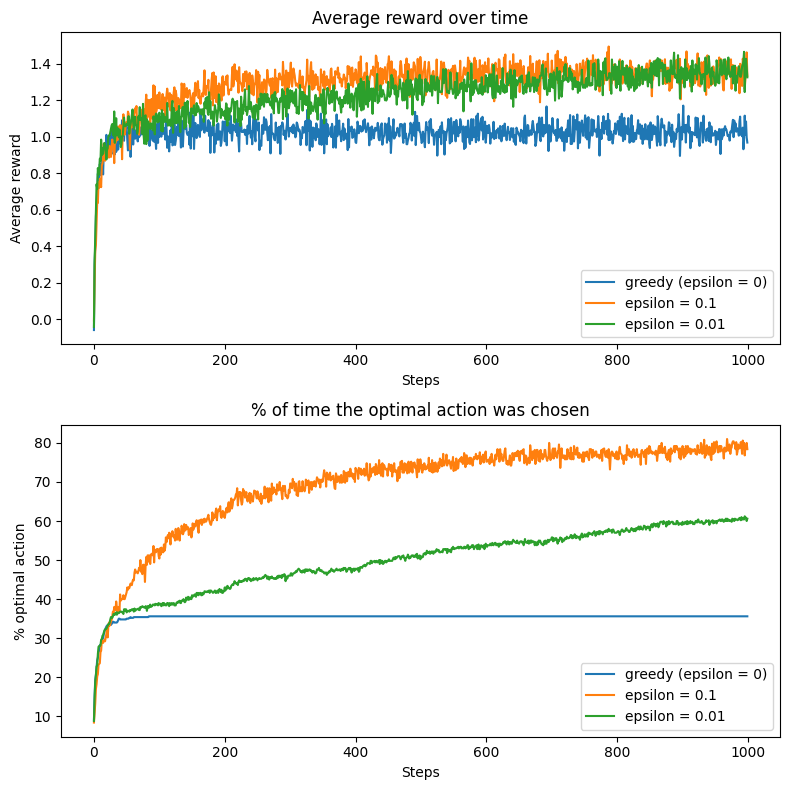

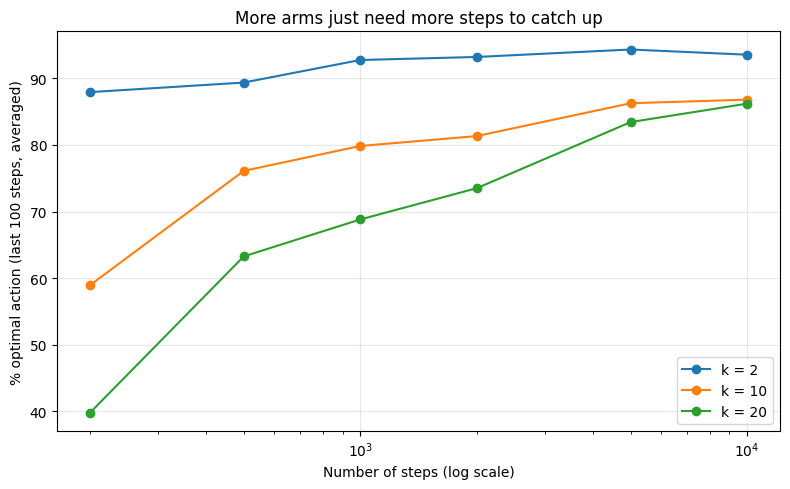

In [14]:
if __name__ == "__main__":
    results = run_experiment(
        epsilons=[0, 0.1, 0.01],
        k=10,
        n_runs=500,
        n_steps=1000,
        seed=42,
    )
    plot_results(results)

    print("\n--- k vs n_steps sweep (epsilon=0.1) ---")
    sweep = run_k_vs_steps_sweep(
        k_values=[2, 10, 20],
        n_steps_values=[200, 500, 1000, 2000, 5000, 10000],
        epsilon=0.1,
        n_runs=300,
        seed=7,
    )
    plot_sweep(sweep, n_steps_values=[200, 500, 1000, 2000, 5000, 10000])
